In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import os

print(f"Current working directory: {os.getcwd()}")

Current working directory: /Users/jpfutalef/Projects/MateReview/notebooks


In [5]:
# Load the data
filepath = Path("../data/REV1-SCOPUS-9/FullExport.csv")
metadata_df = pd.read_csv(filepath)
metadata_df.head()

,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,ISBN,CODEN,PubMed ID,Language of Original Document,Abbreviated Source Title,Document Type,Publication Stage,Open Access,Source,EID
0,Yalçın S.; Yildirim M.; Khan M.A.; Li Y.; Alab...,"Yalçın, Sercan (57206780804); Yildirim, Muhamm...",57206780804; 57211712877; 57222652080; 5721495...,Optimal control strategy to charging and disch...,2026,Energy Reports,15,NaN,109011,NaN,...,NaN,NaN,NaN,English,Energy Rep.,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-105026856721
1,Khanra S.; Kukreja V.K.; Bala I.,"Khanra, Subarna (60243955700); Kukreja, Vijay ...",60243955700; 9737071700; 60067693600,Physics-informed neural networks for different...,2026,Neurocomputing,680,NaN,133317,NaN,...,NaN,NRCGE,NaN,English,Neurocomputing,Review,Final,All Open Access; Hybrid Gold Open Access,Scopus,2-s2.0-105033237171
2,Chen K.; Hui J.; Zhao W.,"Chen, Kunhong (57222067782); Hui, Jizhuang (82...",57222067782; 8230626900; 7403943151,SHURH: A novel multi-domain representation fus...,2026,Journal of Manufacturing Systems,86,NaN,NaN,98,...,NaN,JMSYE,NaN,English,J Manuf Syst,Article,Final,NaN,Scopus,2-s2.0-105032363776
3,Ren W.; Zhou J.; Qiu X.; Qu X.; Lu Y.; Liu H.,"Ren, Weizhe (58311818200); Zhou, Jiahui (60077...",58311818200; 60077297900; 59666006200; 1504705...,Prediction of tension leg platform motion resp...,2026,Ocean Engineering,351,NaN,124502,NaN,...,NaN,NaN,NaN,English,Ocean Eng.,Article,Final,NaN,Scopus,2-s2.0-105030226446
4,Souza M.P.D.O.; Volpatto D.T.; Neto A.M.B.; da...,"Souza, Maurício Prado de Omena (60231595400); ...",60231595400; 57221142720; 58609348800; 5721270...,Modeling flash points of biofuels using thermo...,2026,Fluid Phase Equilibria,605,NaN,114673,NaN,...,NaN,FPEQD,NaN,English,Fluid Phase Equilib.,Article,Final,All Open Access; Hybrid Gold Open Access,Scopus,2-s2.0-105028030941


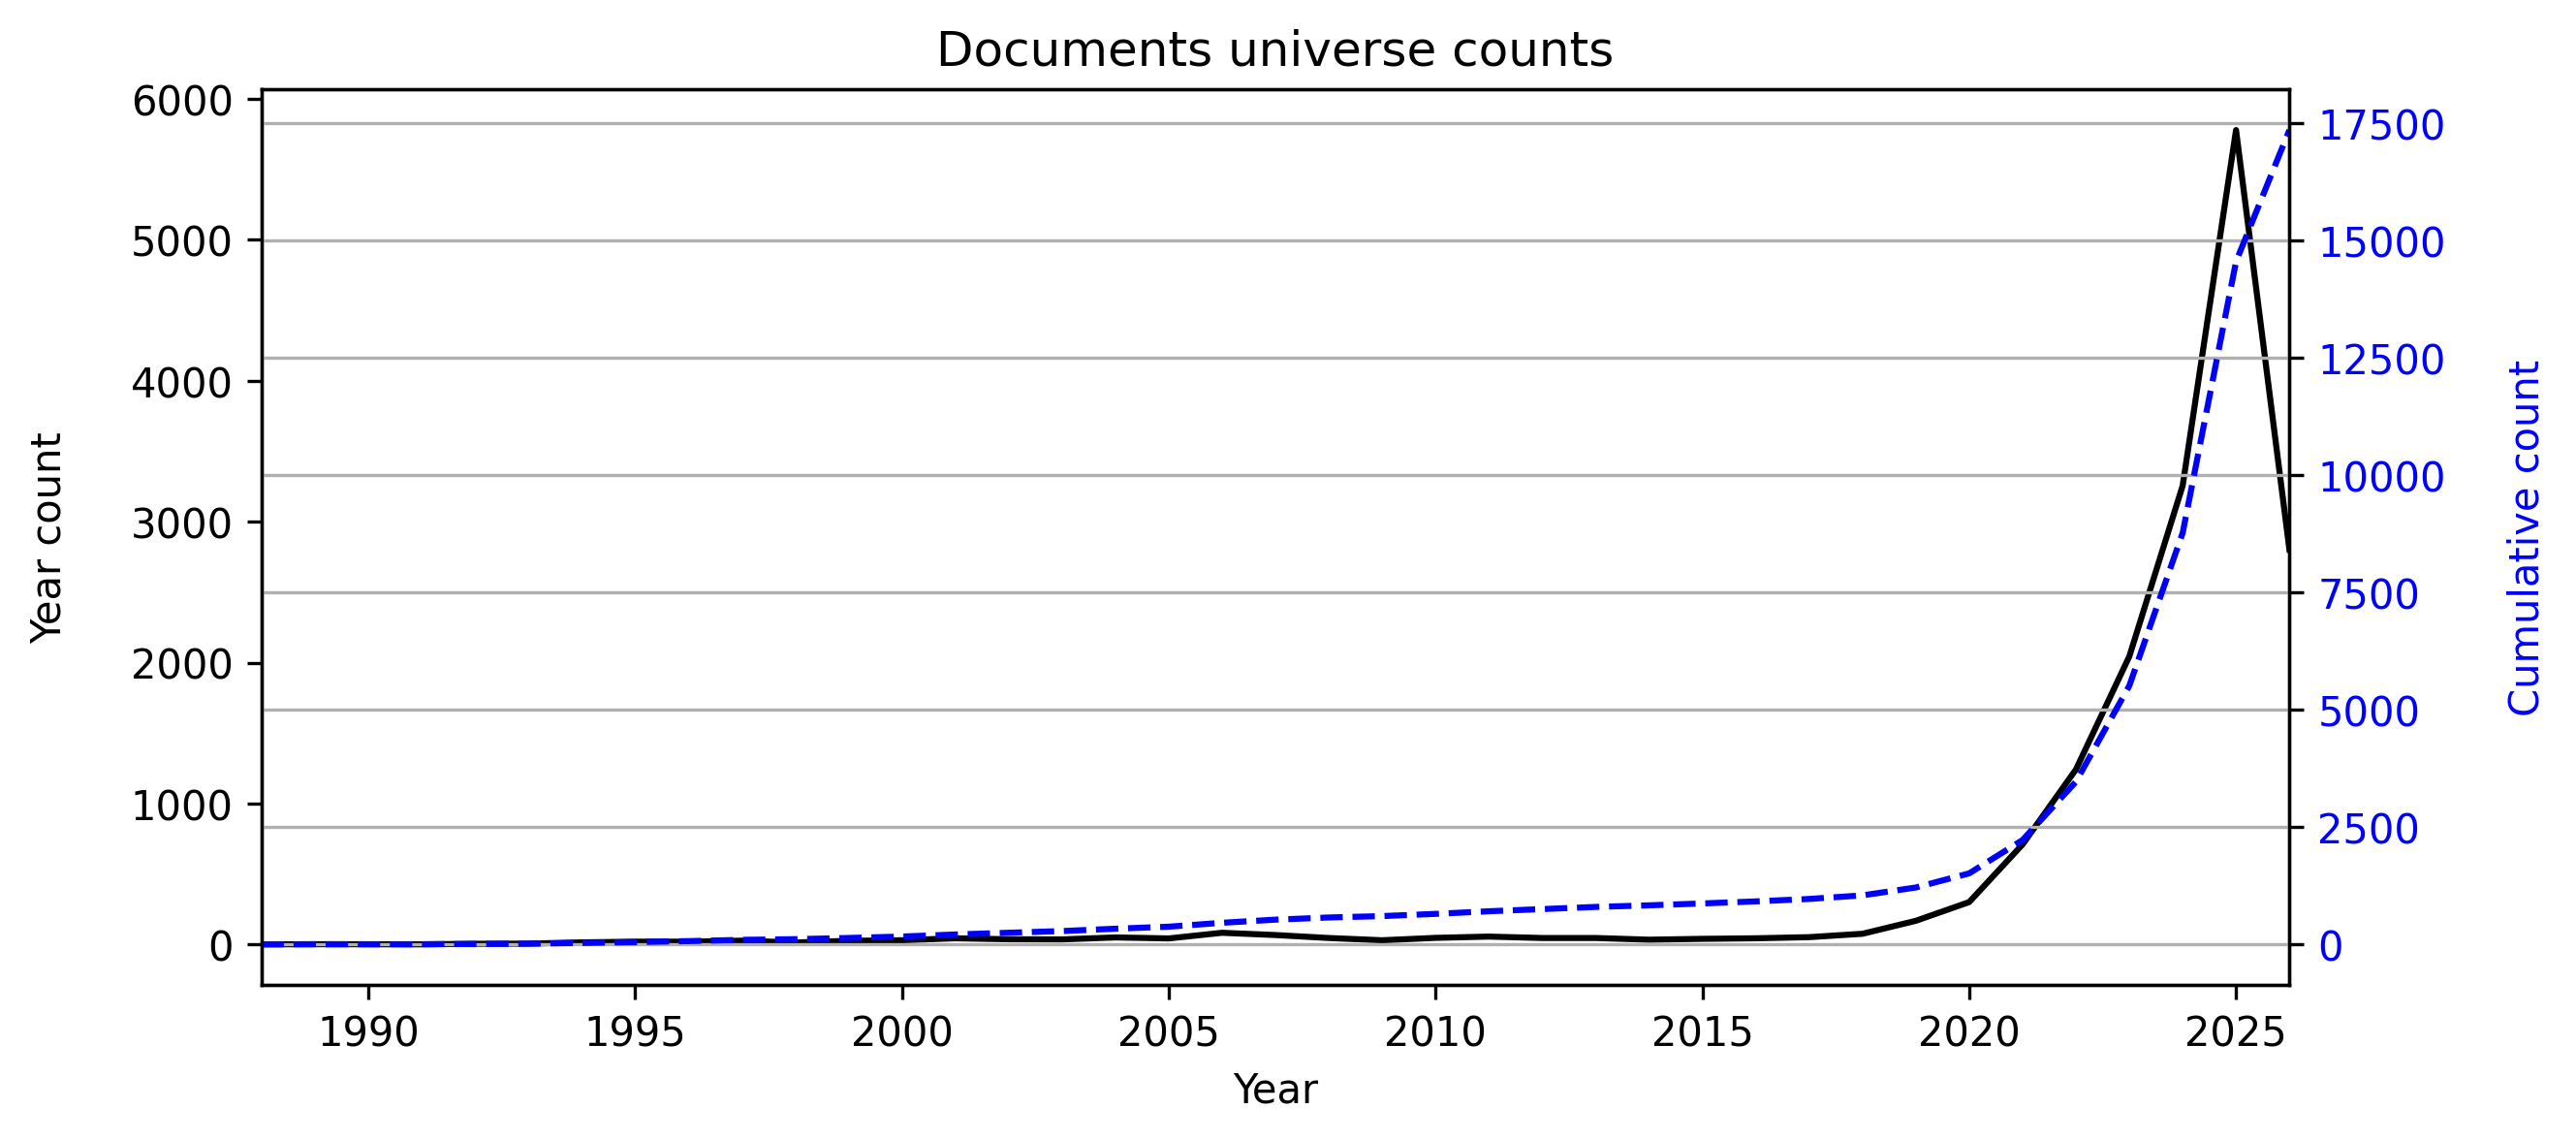

In [73]:
# PLot counts per year
fig, ax = plt.subplots(dpi=300, figsize=(9,4))
metadata_df["Year"].value_counts().sort_index().plot(color="black")
ax.set_ylabel("Year count", labelpad=15)

# Accumulated on right axis
ax2 = ax.twinx()
metadata_df["Year"].value_counts().sort_index().cumsum().plot(color="blue", ax=ax2, linestyle="--")
ax2.set_ylabel("Cumulative count", color="blue")
ax2.tick_params(axis='y', labelcolor="blue")
ax2.set_ylabel("Cumulative count", labelpad=15, color="blue")

plt.title("Documents universe counts")
plt.xlabel("Year")
plt.xlim(1988, 2026)
plt.grid()

In [74]:
def filter_documents(df, keywords=None, year_range=None, doc_types=None):
    """
    Filters a Scopus metadata DataFrame based on keywords, years, and types.
    """
    filtered_df = df.copy()

    # 1. Filter by Year Range (e.g., (2015, 2024))
    if year_range:
        start_year, end_year = year_range
        filtered_df = filtered_df[
            (filtered_df['Year'].astype(int) >= start_year) &
            (filtered_df['Year'].astype(int) <= end_year)
        ]

    # 2. Filter by Document Type (e.g., ['Article', 'Review'])
    if doc_types:
        filtered_df = filtered_df[filtered_df['Document Type'].isin(doc_types)]

    # 3. Filter by Keywords (Searching Title and Abstract)
    if keywords:
        # Create a combined regex pattern for all keywords
        pattern = '|'.join(keywords)
        # Ensure we check both Title and Abstract, handling NaNs
        mask = (
            filtered_df['Title'].str.contains(pattern, case=False, na=False) |
            filtered_df['Abstract'].str.contains(pattern, case=False, na=False)
        )
        filtered_df = filtered_df[mask]

    return filtered_df

In [75]:
# Define your research topics and their associated keywords
research_topics = {
    "Safety": ["safety", "hazard", "risk"],
    "Reliability": ["reliability", "failure rate", "probabilistic"],
    "Maintenance": ["maintenance", "prognostics", "RUL", "health monitoring"]
}

# 1. Track trends and collect all unique document indices for aggregation
trends = {}
all_filtered_indices = set()

for area, kws in research_topics.items():
    area_df = filter_documents(metadata_df, keywords=kws, doc_types=["Article", "Review"])

    # Store for trends
    # Rename column to include keywords for the legend: "Name: [k1, k2...]"
    label = f"{area}: {kws}"
    trends[label] = area_df.groupby('Year').size()

    # Track indices for total unique count
    all_filtered_indices.update(area_df.index)

# 2. Convert to DataFrame for plotting
trend_df = pd.DataFrame(trends).fillna(0)

# Print total count
print(f"Total unique documents across all topics: {len(all_filtered_indices)}")

Total unique documents across all topics: 2656


Total unique documents aggregated: 2656


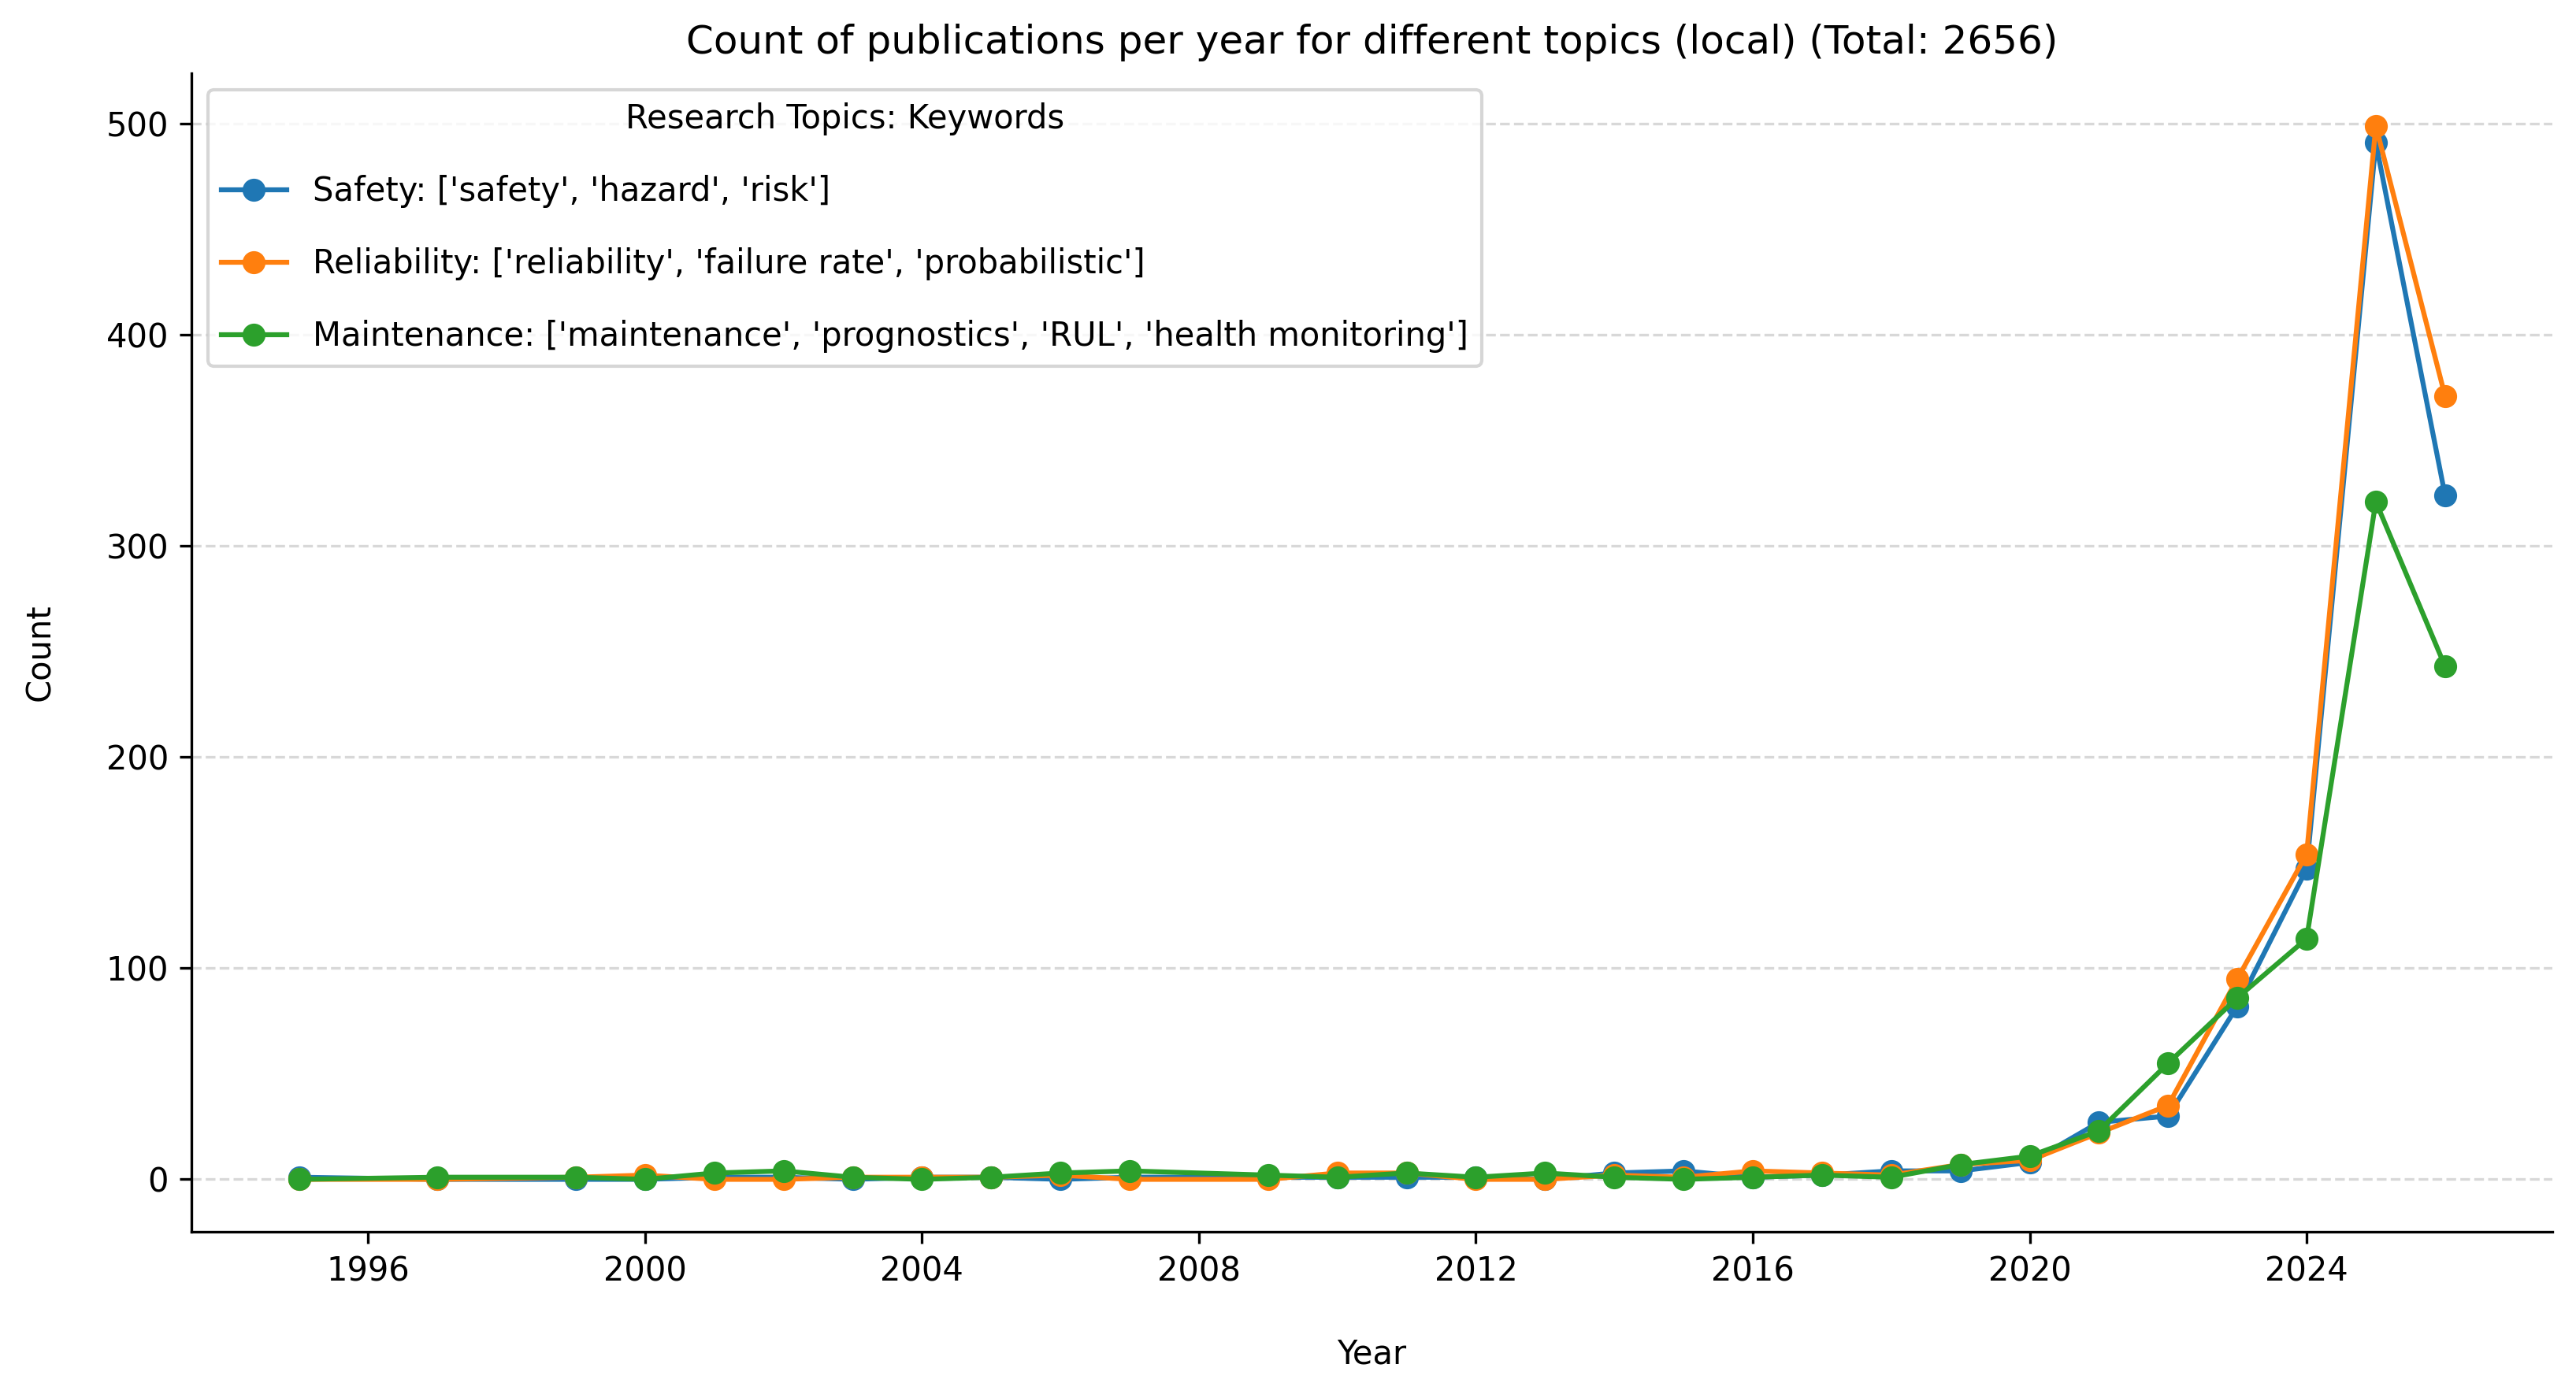

In [77]:
# 4. Styling: Modern, Minimalistic, serif (LaTeX-like)
plt.rcdefaults()


# Professional color palette
fig, ax = plt.subplots(figsize=(11, 6), dpi=300)

for i, column in enumerate(trend_df.columns):
    ax.plot(trend_df.index, trend_df[column], label=column, marker='o')

# Vertical line at 2016
#ax.axvline(x=2016, color='grey', linestyle='--', alpha=0.7)

# Minimalist axis and grid adjustments
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', color='grey', alpha=0.3)

ax.set_title(f"Count of publications per year for different topics (local) (Total: {len(all_filtered_indices)})")
ax.set_xlabel("Year", labelpad=15)
ax.set_ylabel("Count", labelpad=15)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Formatting the legend with set names and keywords
ax.legend(title=f"Research Topics: Keywords", loc='upper left', labelspacing=1.2)

plt.tight_layout()
print(f"Total unique documents aggregated: {len(all_filtered_indices)}")

In [78]:
# Get from 2016 onward
all_kwds = [kw for kws in research_topics.values() for kw in kws]
filtered2016_df = filter_documents(
    metadata_df,
    keywords=all_kwds,
    year_range=(2020, 2026),
    doc_types=["Article", "Review"]
)

print(f"Number of papers from 2016: {len(filtered2016_df)}")
print(f"   - keywords: {all_kwds}")

Number of papers from 2016: 2565
   - keywords: ['safety', 'hazard', 'risk', 'reliability', 'failure rate', 'probabilistic', 'maintenance', 'prognostics', 'RUL', 'health monitoring']


In [58]:
# Extract randomly some samples from the filtered data and print information
sample_size = 5
sample_df = filtered2016_df.sample(sample_size)
for idx, row in sample_df.iterrows():
    print(f"Title: {row['Title']}")
    print(f"  Year: {row['Year']}")
    print(f"  Source: {row['Source title']}")
    print(f"  DOI: {row['DOI']}")
    #print(f"Abstract: {row['Abstract']}...")  # Print first 200 characters of the abstract
    print("-" * 80)

Title: A voltage sag detection framework based on constraint-driven neural networks
  Year: 2025
  Source: International Journal of Electrical Power and Energy Systems
  DOI: 10.1016/j.ijepes.2025.111420
--------------------------------------------------------------------------------
Title: Hybrid modeling of multibody vehicles with partially known physics: discovering complex behaviors of tires
  Year: 2025
  Source: Multibody System Dynamics
  DOI: 10.1007/s11044-024-09983-3
--------------------------------------------------------------------------------
Title: Physics-Informed Deep Learning for Bearing Remaining Useful Life: Adaptive Paris-Law Regularization with Gaussian Processes
  Year: 2026
  Source: Integrating Materials and Manufacturing Innovation
  DOI: 10.1007/s40192-026-00441-w
--------------------------------------------------------------------------------
Title: Physics-informed neural networks for linear elastic fracture mechanics: Application of assessing stress intens

In [79]:
# save the filtered data to a new CSV file
output_path = Path("../data/REV1-SCOPUS-9/ASREWVIEW-FilteredPapers.csv")
filtered2016_df.to_csv(output_path, index=False)
print(f"Filtered data saved to: {output_path}")

Filtered data saved to: ../data/REV1-SCOPUS-9/ASREWVIEW-FilteredPapers.csv


Number of papers after filtering: 121


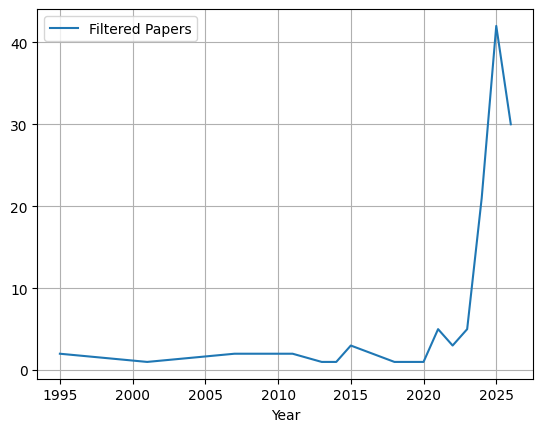

In [8]:
# Filter by keywords in the specified columns
keywords = ["safety", "risk", "reliablity"]
filtered_df = metadata_df[metadata_df["Title"].str.contains("|".join(keywords), case=False, na=False)]
print(f"Number of papers after filtering: {len(filtered_df)}")

# Plot counts per year for the filtered data on top of the original data
fig, ax = plt.subplots()
# metadata_df["Year"].value_counts().sort_index().plot(label="All Papers", ax=ax)
filtered_df["Year"].value_counts().sort_index().plot(label="Filtered Papers", ax=ax)
plt.legend()
plt.grid()